In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"🛑 Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [5]:
doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(doubs_data)
doubs_data.dropna(axis=1, thresh=threshold, inplace=True)

doubs_data.dropna(inplace=True)

In [6]:
doubs_data.shape

(2679, 62)

In [7]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnies'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnies'].isna().sum()
print(f"Nombre de casernes sans id_compagnies : {none_count}")

print(caserne[['compagnie', 'id_compagnies']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

Nombre de casernes sans id_compagnies : 0
         compagnie  id_compagnies
0         Besançon            1.0
1  Baume-les-Dames            2.0
2      Montbéliard            6.0
3       Pontarlier            4.0
4      Montbéliard            6.0


In [8]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_data['id_compagnies'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_data.at[idx, 'id_compagnies'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_data.at[idx, 'id_compagnies'] = best_company_id

print(doubs_data[['hex_id', 'id_compagnies']].head())

            hex_id id_compagnies
0  871f820aaffffff           4.0
1  871f82d61ffffff          12.0
2  871f82d61ffffff          12.0
3  871f82d4dffffff           1.0
4  871f82700ffffff           5.0


In [9]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
caserne = caserne.to_crs(epsg=4326)

doubs_data['id_caserne'] = None
doubs_data['distance'] = None

for idx, hexagone in doubs_data.iterrows():
    casernes_same_company = caserne[caserne['id_compagnies'] == hexagone['id_compagnies']]

    if casernes_same_company.empty:
        continue

    distances = casernes_same_company.geometry.distance(hexagone['geometry'])

    nearest_caserne_idx = distances.idxmin()
    nearest_caserne = casernes_same_company.loc[nearest_caserne_idx]

    doubs_data.at[idx, 'id_caserne'] = nearest_caserne['id_pg']
    doubs_data.at[idx, 'distance'] = distances.min()

print(doubs_data[['hex_id', 'id_compagnies', 'id_caserne', 'distance']].head())

Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



            hex_id id_compagnies id_caserne  distance
0  871f820aaffffff           4.0     840709       0.0
1  871f82d61ffffff          12.0     840704  0.005327
2  871f82d61ffffff          12.0     840704  0.005327
3  871f82d4dffffff           1.0     840698  0.039716
4  871f82700ffffff           5.0     840701  0.010387


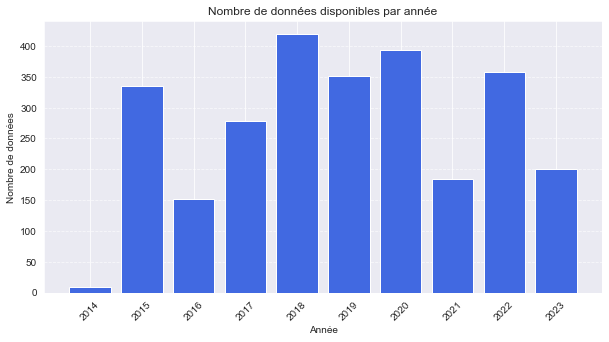

In [10]:
year_counts = doubs_data["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index, year_counts.values, color="royalblue")
plt.xlabel("Année")
plt.ylabel("Nombre de données")
plt.title("Nombre de données disponibles par année")
plt.xticks(year_counts.index, rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [11]:
print(year_counts)

2014.0      9
2015.0    335
2016.0    152
2017.0    278
2018.0    420
2019.0    351
2020.0    393
2021.0    184
2022.0    357
2023.0    200
Name: year, dtype: int64


In [12]:
doubs_data.columns

Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'duree_minutes', 'geometry', 'duree', 'centroid',
       'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'scale0',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister', 'id_compagnies', 'id_caserne',
       'distance'],
      dtype='object')

In [13]:
cols_to_drop = [
    'raison_sortie', 'label', 'departement', 'duree',
    'index', 'longitude', 'latitude', 'sinister', 'id_caserne', 'date_debut', 'date_fin', 'year', 'scale0', 'hour', 'month', 'weekday', 'distance'
]

doubs_data = doubs_data.drop(columns=[col for col in cols_to_drop if col in doubs_data.columns])

In [14]:
doubs_data.columns

Index(['hex_id', 'date', 'duree_minutes', 'geometry', 'centroid',
       'centroid_lon', 'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI',
       'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path',
       'population', 'elevation', 'foret_encoder', 'highway_encoder',
       'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas',
       'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier',
       'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'id_compagnies'],
      dtype='object')

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -193.308183   365.771043  35.301036  49.568009  0.030354   
1   2.1  -207.285164   379.748023  37.570279  50.756412  0.041264   
2   2.2  -221.262145   393.725004  37.570279  50.756412  0.041264   
3   2.3  -235.239125   407.701985  37.456715  51.824335  0.063704   
4   2.4  -249.216106   421.678965  38.777120  55.530498  0.042433   
5   2.5  -263.193087   435.655946  37.191344  54.357449  0.082462   
6   2.6  -277.170067   449.632927  37.416691  53.991449 -0.016037   
7   2.7  -291.147048   463.609907  36.014943  52.960120  0.022409   
8   2.8  -305.124029   477.586888  36.578454  55.067346  0.026893   
9   2.9  -319.101009   491.563869  36.578454  55.067346  0.026893   
10  3.0  -333.077990   505.540849  37.234171  57.746589  0.023126   
11  3.1  -347.054971   519.517830  36.426815  56.146294  0.076518   
12  3.2  -361.031951   533.494811  37.683943  57.799374  0.021339   
13  3.3  -375.008932   547.471791 

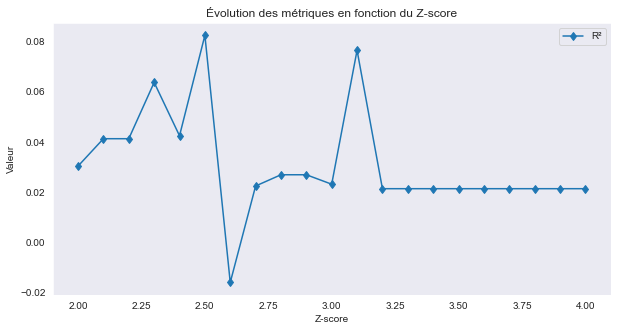

In [15]:
df = doubs_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

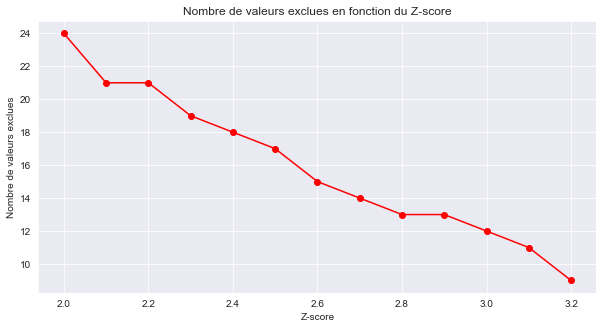

In [16]:
df = doubs_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

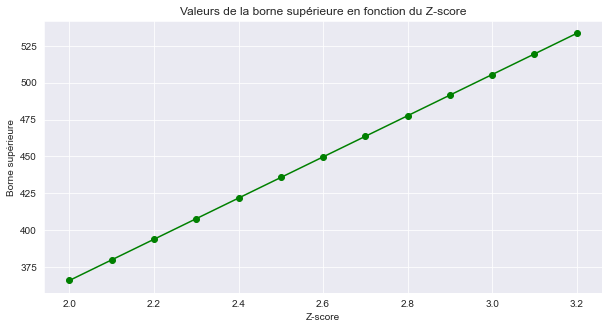

In [17]:
df = doubs_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [18]:
top_35_values = df['duree_minutes'].nlargest(35)

print(top_35_values)

1716    3885.850000
1199    3025.100000
1263    2753.933333
954     1725.383333
234     1667.683333
836     1629.883333
228     1625.983333
363     1500.500000
1112     920.333333
1341     531.866667
2583     530.733333
2590     510.183333
2853     504.333333
242      466.100000
2553     458.316667
160      443.816667
1931     437.516667
1173     435.516667
199      414.416667
2663     402.866667
505      398.400000
1804     373.866667
2419     371.916667
68       367.333333
1772     363.283333
260      359.183333
2778     358.000000
2767     357.716667
2816     355.216667
656      347.350000
0        345.533333
362      344.300000
937      342.533333
2297     331.250000
1009     326.916667
Name: duree_minutes, dtype: float64


In [19]:
doubs_data['z_score'] = np.abs(zscore(doubs_data['duree_minutes']))

doubs_data_filtered = doubs_data[doubs_data['z_score'] <= 2.9].drop(columns=['z_score'])

values_removed = len(doubs_data) - len(doubs_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(doubs_data) * 100:.2f}%")

Nombre de valeurs supprimées : 13
Pourcentage des données supprimées : 0.49%


In [20]:
doubs_data_filtered.columns

Index(['hex_id', 'date', 'duree_minutes', 'geometry', 'centroid',
       'centroid_lon', 'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI',
       'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path',
       'population', 'elevation', 'foret_encoder', 'highway_encoder',
       'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas',
       'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier',
       'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'id_compagnies'],
      dtype='object')

In [21]:
def get_saison_annee(date):
    mois = date.month
    annee = date.year

    if mois in [12, 1, 2]:
        saison = "hiver"
        annee = annee if mois != 12 else annee + 1
    elif mois in [3, 4, 5]:
        saison = "printemps"
    elif mois in [6, 7, 8]:
        saison = "été"
    else:
        saison = "automne"

    return f"{saison} {annee}"

doubs_data_filtered["date"] = pd.to_datetime(doubs_data_filtered["date"])
doubs_data_filtered["saison_annee"] = doubs_data_filtered["date"].apply(get_saison_annee)

moyennes_saison_hex = (
    doubs_data_filtered.groupby(["hex_id", "saison_annee"])
    .agg({**{col: "mean" for col in doubs_data_filtered.select_dtypes(include="number").columns},
          "geometry": "first"})
    .reset_index()
)

print(moyennes_saison_hex.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff  printemps 2019     163.133333      6.350198     47.477082   
1  871f80492ffffff  printemps 2022      61.850000      6.350198     47.477082   
2  871f80492ffffff  printemps 2023      72.083333      6.350198     47.477082   
3  871f80492ffffff        été 2015      40.850000      6.350198     47.477082   
4  871f80492ffffff        été 2017     197.783333      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...     water       tree  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  0.012568  35.314817   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  0.012568  35.314817   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  0.012568  35.314817   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  0.012568  35.314817   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  0.012568  35.314817   

       grass     crops     shrub

In [22]:
moyennes_saison_hex = gpd.GeoDataFrame(moyennes_saison_hex, geometry="geometry")

In [23]:
import geopandas as gpd
from shapely.geometry import Polygon

def assign_compagnie(df, compagnies):
    df['id_compagnies'] = None

    for idx, row in df.iterrows():
        hex_geom = row['geometry']
        best_compagnie = None
        max_area = 0

        for _, compagnie_row in compagnies.iterrows():
            comp_geom = compagnie_row['geometry']

            if hex_geom.intersects(comp_geom):
                intersection = hex_geom.intersection(comp_geom)
                intersection_area = intersection.area

                if intersection_area > max_area:
                    best_compagnie = compagnie_row['id']
                    max_area = intersection_area

        if best_compagnie is not None:
            df.at[idx, 'id_compagnies'] = best_compagnie

    return df

# Appliquer la fonction à votre DataFrame 'moyennes_saison_hex' et 'compagnies'
moyennes_saison_hex = assign_compagnie(moyennes_saison_hex, compagnies)

In [24]:
compagnies.columns

Index(['id', 'nom', 'num', 'geometry'], dtype='object')

In [25]:
hexagones_uniques = moyennes_saison_hex["hex_id"].unique()

np.random.seed(42)
hex_train = np.random.choice(hexagones_uniques, size=int(0.7 * len(hexagones_uniques)), replace=False)

doubs_train = moyennes_saison_hex[moyennes_saison_hex["hex_id"].isin(hex_train)]
doubs_test = moyennes_saison_hex[~moyennes_saison_hex["hex_id"].isin(hex_train)]

print(f"Taille du train : {len(doubs_train)}, Taille du test : {len(doubs_test)}")

Taille du train : 1358, Taille du test : 643


In [26]:
doubs_train.columns

Index(['hex_id', 'saison_annee', 'duree_minutes', 'centroid_lon',
       'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'geometry',
       'id_compagnies'],
      dtype='object')

In [27]:
def saison_to_index(saison_annee):
    saison, annee = saison_annee.split()
    annee = int(annee)
    saison_dict = {"hiver": 0.0, "printemps": 0.25, "été": 0.5, "automne": 0.75}
    return annee + saison_dict[saison]

def find_neighbors(df, reference_df, max_distance_km=4):
    df = df.copy()

    df["id_compagnies"] = df["id_compagnies"]

    df["saison_index"] = df["saison_annee"].apply(saison_to_index)
    reference_df["saison_index"] = reference_df["saison_annee"].apply(saison_to_index)

    df["centroid"] = df.geometry.centroid
    reference_df["centroid"] = reference_df.geometry.centroid

    reference_points = np.array([[geom.x, geom.y] for geom in reference_df["centroid"]])
    tree = cKDTree(reference_points)

    df["hex_voisins"] = df.apply(lambda x: set(), axis=1)

    for idx, row in df.iterrows():
        hex_id = row["hex_id"]
        centroid = row["centroid"]

        dists, indices = tree.query([centroid.x, centroid.y], k=7)

        voisins = set()

        for dist, i in zip(dists, indices):
            if dist <= max_distance_km:
                voisin_id = reference_df.iloc[i]["hex_id"]

                if voisin_id != hex_id:
                    voisins.add(voisin_id)

        df.at[idx, "hex_voisins"] = list(voisins)

    return df

doubs_train = find_neighbors(doubs_train, doubs_train)
doubs_test = find_neighbors(doubs_test, doubs_train)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [28]:
def calculer_statistiques_par_compagnie(df):
    stats_df = df.groupby('id_compagnies')['duree_minutes'].agg(
        moyenne='mean',
        ecart_type='std',
        mediane='median',
        min='min',
        max='max',
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75)
    ).reset_index()

    return stats_df

compagnies_stats = calculer_statistiques_par_compagnie(doubs_data_filtered)

print(compagnies_stats.head())

   id_compagnies     moyenne  ecart_type     mediane        min         max  \
0            1.0   61.549203   47.436291   49.916667   1.150000  458.316667   
1            2.0   84.968724   47.366281   71.758333   2.850000  276.766667   
2            3.0  119.923261   73.222113  105.733333  27.033333  402.866667   
3            4.0   78.249563   47.624350   68.850000  17.300000  345.533333   
4            5.0   94.533197   64.042011   76.175000  26.533333  443.816667   

          q1          q3  
0  35.654167   70.583333  
1  48.579167  114.050000  
2  66.183333  140.641667  
3  46.800000  101.066667  
4  60.112500  100.883333  


In [29]:
doubs_train.columns

Index(['hex_id', 'saison_annee', 'duree_minutes', 'centroid_lon',
       'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'geometry',
       'id_compagnies', 'saison_index', 'centroid', 'hex_voisins'],
      dtype='object')

In [30]:
def calculer_statistiques_voisins(df, reference_df):
    df = df.copy()

    df["saison_index"] = df["saison_annee"].apply(saison_to_index)
    reference_df["saison_index"] = reference_df["saison_annee"].apply(saison_to_index)

    stats_columns = ['moyenne', 'ecart_type', 'mediane', 'min', 'max', 'q1', 'q3']
    for col in stats_columns:
        df[col] = None

    for idx, row in df.iterrows():
        hex_id = row["hex_id"]
        saison_ref = row["saison_index"]
        voisins = row["hex_voisins"]

        voisins_data = reference_df[reference_df["hex_id"].isin(voisins)]
        voisins_anciens = voisins_data[voisins_data["saison_index"] < saison_ref]

        if not voisins_anciens.empty:
            durees = voisins_anciens["duree_minutes"]

            df.at[idx, "moyenne"] = durees.mean()
            df.at[idx, "ecart_type"] = durees.std()
            df.at[idx, "mediane"] = durees.median()
            df.at[idx, "min"] = durees.min()
            df.at[idx, "max"] = durees.max()
            df.at[idx, "q1"] = durees.quantile(0.25)
            df.at[idx, "q3"] = durees.quantile(0.75)

    if "id_compagnies" not in df.columns:
        print("Attention : 'id_compagnies' a été perdu ! Ajout en fusionnant avec reference_df.")

        df = df.merge(reference_df[['hex_id', 'id_compagnies']], on='hex_id', how='left')

    return df

doubs_train_stats = calculer_statistiques_voisins(doubs_train, doubs_train)
doubs_test_stats = calculer_statistiques_voisins(doubs_test, doubs_train)

print(doubs_train_stats[['hex_id', 'id_compagnies', 'moyenne', 'ecart_type', 'mediane', 'min', 'max', 'q1', 'q3']].head())

            hex_id id_compagnies    moyenne ecart_type    mediane    min  \
0  871f80492ffffff           2.0  81.108333  32.043722  81.108333  58.45   
1  871f80492ffffff           2.0  81.108333  32.043722  81.108333  58.45   
2  871f80492ffffff           2.0  81.108333  32.043722  81.108333  58.45   
3  871f80492ffffff           2.0       None       None       None   None   
4  871f80492ffffff           2.0  81.108333  32.043722  81.108333  58.45   

          max         q1       q3  
0  103.766667  69.779167  92.4375  
1  103.766667  69.779167  92.4375  
2  103.766667  69.779167  92.4375  
3        None       None     None  
4  103.766667  69.779167  92.4375  


In [31]:
print(doubs_data_filtered.columns)

doubs_train = doubs_train.merge(doubs_data_filtered[['hex_id', 'id_compagnies']], on='hex_id', how='left')
doubs_test = doubs_test.merge(doubs_data_filtered[['hex_id', 'id_compagnies']], on='hex_id', how='left')

print(doubs_train.head())
print(doubs_test.head())

Index(['hex_id', 'date', 'duree_minutes', 'geometry', 'centroid',
       'centroid_lon', 'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI',
       'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path',
       'population', 'elevation', 'foret_encoder', 'highway_encoder',
       'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas',
       'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier',
       'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'id_compagnies',
       'saison_annee'],
      dtype='object')
            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff  printemps 2019     163.133333      6.350198     47.477082   
1  871f80492ffffff  printemps 2019     163.133333      6.350198     47.477082   
2  871f80492ffffff  printemps 2019 

In [32]:
def remplacer_none_par_compagnie(df, compagnies_stats):
    df_copy = df.copy()
    df_copy = df_copy.merge(compagnies_stats, on="id_compagnies", how="left", suffixes=("", "_compagnie"))
    stats_cols = ["moyenne", "ecart_type", "mediane", "min", "max", "q1", "q3"]

    for col in stats_cols:
        df_copy[col] = df_copy[col].fillna(df_copy[f"{col}_compagnie"])
        df_copy.drop(columns=[f"{col}_compagnie"], inplace=True)

    return df_copy

doubs_train_stats = remplacer_none_par_compagnie(doubs_train_stats, compagnies_stats)
doubs_test_stats = remplacer_none_par_compagnie(doubs_test_stats, compagnies_stats)

print(doubs_train_stats[['hex_id', 'id_compagnies', 'moyenne', 'ecart_type', 'mediane', 'min', 'max', 'q1', 'q3']].head())

            hex_id id_compagnies    moyenne  ecart_type    mediane    min  \
0  871f80492ffffff           2.0  81.108333   32.043722  81.108333  58.45   
1  871f80492ffffff           2.0  81.108333   32.043722  81.108333  58.45   
2  871f80492ffffff           2.0  81.108333   32.043722  81.108333  58.45   
3  871f80492ffffff           2.0  84.968724   47.366281  71.758333   2.85   
4  871f80492ffffff           2.0  81.108333   32.043722  81.108333  58.45   

          max         q1        q3  
0  103.766667  69.779167   92.4375  
1  103.766667  69.779167   92.4375  
2  103.766667  69.779167   92.4375  
3  276.766667  48.579167  114.0500  
4  103.766667  69.779167   92.4375  


In [33]:
print(doubs_train_stats.columns)

Index(['hex_id', 'saison_annee', 'duree_minutes', 'centroid_lon',
       'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'geometry',
       'id_compagnies', 'saison_index', 'centroid', 'hex_voisins', 'moyenne',
       'ecart_type', 'mediane', 'min', 'max', 'q1', 'q3'],
      dtype='object')


In [34]:
X_train = doubs_train_stats.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'saison_annee', 'id_compagnies', 'centroid', 'hex_voisins'])
y_train = doubs_train_stats['duree_minutes']

X_test = doubs_test_stats.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'saison_annee', 'id_compagnies', 'centroid', 'hex_voisins'])
y_test = doubs_test_stats['duree_minutes']

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erreur quadratique moyenne : {mse}")
print(f"R² : {r2}")

coefficients = pd.DataFrame(model.coef_, X_train.columns, columns=["Coefficient"])
print(coefficients)

Erreur quadratique moyenne : 3136.780417032719
R² : 0.07083064749679058
                        Coefficient
centroid_lon          -1.722187e+01
centroid_lat           5.247646e+01
NDVI                   2.913183e+02
NDMI                  -1.960414e+01
NDBI                   1.960414e+01
NDSI                  -1.328302e+02
NDWI                   4.224041e+02
PasDeRoute             2.779407e+00
motorway              -2.026781e+00
primary               -3.159115e+00
secondary              2.043049e+00
tertiary              -1.728565e-01
path                   5.362952e-01
population            -4.097029e-03
elevation              1.997916e-02
foret_encoder          1.806661e-02
highway_encoder        8.432472e-10
PasDeforet            -1.893110e+00
Châtaignier           -9.640821e-11
Chênes décidus        -1.519314e+00
Conifères              1.909992e+00
Douglas                3.659503e-01
Feuillus              -2.228058e+00
Hêtre                 -2.316346e+00
Mixte                 -1.145

[0]	train-rmse:52.25128	test-rmse:57.46717
[10]	train-rmse:42.11176	test-rmse:55.81217
[20]	train-rmse:37.59579	test-rmse:55.60502
[28]	train-rmse:35.17406	test-rmse:55.95408
🔹 MSE: 3130.86
🔹 RMSE: 55.95
🔹 MAE: 38.77
🔹 R²: 0.07


<Figure size 720x432 with 0 Axes>

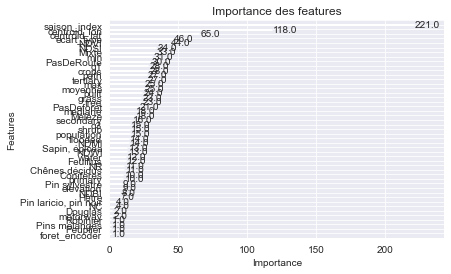

In [35]:
cols_to_drop = ['hex_id', 'geometry', 'saison_annee', 'id_compagnies', 'centroid', 'hex_voisins']

X_train = doubs_train_stats.drop(columns=[col for col in cols_to_drop if col in doubs_train_stats.columns] + ["duree_minutes"])
y_train = doubs_train_stats["duree_minutes"]

X_test = doubs_test_stats.drop(columns=[col for col in cols_to_drop if col in doubs_test_stats.columns] + ["duree_minutes"])
y_test = doubs_test_stats["duree_minutes"]

dtrain = DMatrix(X_train, label=y_train)
dtest = DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",  # Régression
    "eval_metric": "rmse",  # Erreur quadratique moyenne
    "eta": 0.1,  # Taux d'apprentissage
    "max_depth": 6,  # Profondeur de l'arbre
    "subsample": 0.8,  # Échantillonnage des données
    "colsample_bytree": 0.8,  # Échantillonnage des features
}

model = train(params, dtrain, num_boost_round=100, evals=[(dtrain, "train"), (dtest, "test")], early_stopping_rounds=10, verbose_eval=10)

y_pred = model.predict(dtest)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"🔹 MSE: {mse:.2f}")
print(f"🔹 RMSE: {rmse:.2f}")
print(f"🔹 MAE: {mae:.2f}")
print(f"🔹 R²: {r2:.2f}")

plt.figure(figsize=(10, 6))
plot_importance(model, importance_type="weight", xlabel="Importance", title="Importance des features")
plt.show()

In [36]:
"""from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(objective="reg:squarederror", random_state=42)

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "n_estimators": [100, 300, 500],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "lambda": [0, 1, 10]
}

grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=1)

X_train = doubs_train_stats.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'saison_annee', 'id_compagnies', 'centroid', 'hex_voisins'])
y_train = doubs_train_stats['duree_minutes']

grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur R² :", grid_search.best_score_)"""

'from sklearn.model_selection import GridSearchCV\nfrom xgboost import XGBRegressor\n\nxgb = XGBRegressor(objective="reg:squarederror", random_state=42)\n\nparam_grid = {\n    "max_depth": [3, 5, 7],\n    "learning_rate": [0.01, 0.1, 0.2],\n    "n_estimators": [100, 300, 500],\n    "subsample": [0.7, 0.9, 1.0],\n    "colsample_bytree": [0.7, 0.9, 1.0],\n    "lambda": [0, 1, 10]\n}\n\ngrid_search = GridSearchCV(xgb, param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=1)\n\nX_train = doubs_train_stats.drop(columns=[\'duree_minutes\', \'hex_id\', \'geometry\', \'saison_annee\', \'id_compagnies\', \'centroid\', \'hex_voisins\'])\ny_train = doubs_train_stats[\'duree_minutes\']\n\ngrid_search.fit(X_train, y_train)\n\nprint("Meilleurs paramètres :", grid_search.best_params_)\nprint("Meilleur R² :", grid_search.best_score_)'

In [37]:
"""Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Meilleurs paramètres : {'colsample_bytree': 0.7, 'lambda': 10, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7}
Meilleur R² : 0.10112143679319337"""

"Fitting 5 folds for each of 729 candidates, totalling 3645 fits\nMeilleurs paramètres : {'colsample_bytree': 0.7, 'lambda': 10, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7}\nMeilleur R² : 0.10112143679319337"

[13:39:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "lambda_" } are not used.



R² sur les données d'entraînement : 0.6354
R² sur les données de test : 0.0934


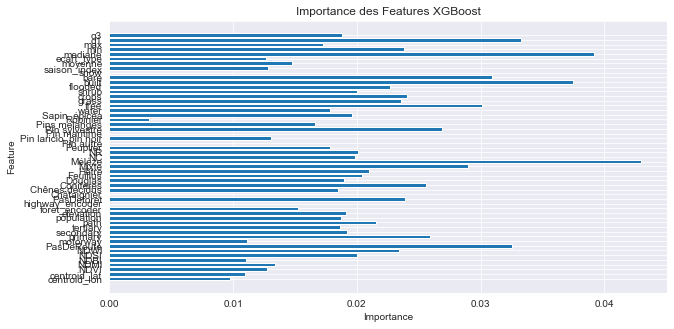

[0]	train-rmse:53.60253	train-r2:0.00424	test-rmse:58.06884	test-r2:0.00116
[1]	train-rmse:53.46927	train-r2:0.00918	test-rmse:58.01190	test-r2:0.00312
[2]	train-rmse:53.37129	train-r2:0.01281	test-rmse:57.97623	test-r2:0.00434
[3]	train-rmse:53.24249	train-r2:0.01757	test-rmse:57.94389	test-r2:0.00545
[4]	train-rmse:53.10973	train-r2:0.02246	test-rmse:57.92187	test-r2:0.00621
[5]	train-rmse:53.00006	train-r2:0.02650	test-rmse:57.89883	test-r2:0.00700
[6]	train-rmse:52.87168	train-r2:0.03121	test-rmse:57.85799	test-r2:0.00840
[7]	train-rmse:52.76440	train-r2:0.03513	test-rmse:57.82479	test-r2:0.00954
[8]	train-rmse:52.64277	train-r2:0.03958	test-rmse:57.80080	test-r2:0.01036
[9]	train-rmse:52.53761	train-r2:0.04341	test-rmse:57.76190	test-r2:0.01169
[10]	train-rmse:52.41502	train-r2:0.04787	test-rmse:57.71812	test-r2:0.01319


`feval` is deprecated, use `custom_metric` instead.  They have different behavior when custom objective is also used.See https://xgboost.readthedocs.io/en/latest/tutorials/custom_metric_obj.html for details on the `custom_metric`.
[13:39:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.



[11]	train-rmse:52.30088	train-r2:0.05201	test-rmse:57.68558	test-r2:0.01430
[12]	train-rmse:52.18355	train-r2:0.05626	test-rmse:57.63615	test-r2:0.01599
[13]	train-rmse:52.07550	train-r2:0.06016	test-rmse:57.59401	test-r2:0.01743
[14]	train-rmse:51.96360	train-r2:0.06420	test-rmse:57.56225	test-r2:0.01851
[15]	train-rmse:51.85169	train-r2:0.06822	test-rmse:57.52648	test-r2:0.01973
[16]	train-rmse:51.74468	train-r2:0.07207	test-rmse:57.47164	test-r2:0.02160
[17]	train-rmse:51.64646	train-r2:0.07559	test-rmse:57.43065	test-r2:0.02299
[18]	train-rmse:51.53574	train-r2:0.07955	test-rmse:57.40152	test-r2:0.02398
[19]	train-rmse:51.41738	train-r2:0.08377	test-rmse:57.38877	test-r2:0.02442
[20]	train-rmse:51.31907	train-r2:0.08727	test-rmse:57.36301	test-r2:0.02529


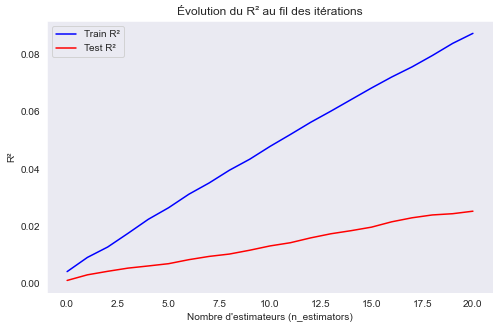

In [38]:
def r2_metric(preds, dtrain):
    labels = dtrain.get_label()
    return 'r2', r2_score(labels, preds)

best_params = {
    'colsample_bytree': 0.7,
    'lambda': 10,
    'learning_rate': 0.01,
    'max_depth': 7,
    'n_estimators': 300,
    'subsample': 0.7
}

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    colsample_bytree=best_params['colsample_bytree'],
    lambda_=best_params['lambda'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    n_estimators=best_params['n_estimators'],
    subsample=best_params['subsample']
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

train_r2 = r2_score(y_train, xgb_model.predict(X_train))
test_r2 = r2_score(y_test, y_pred)

print(f"R² sur les données d'entraînement : {train_r2:.4f}")
print(f"R² sur les données de test : {test_r2:.4f}")

plt.figure(figsize=(10, 5))
plt.barh(X_train.columns, xgb_model.feature_importances_)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Importance des Features XGBoost")
plt.show()

dtrain = DMatrix(X_train, label=y_train)
dtest = DMatrix(X_test, label=y_test)

evals = [(dtrain, 'train'), (dtest, 'test')]
evals_result = {}

bst = train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=best_params['n_estimators'],
    evals=evals,
    early_stopping_rounds=20,
    evals_result=evals_result,
    verbose_eval=True,
    feval=r2_metric
)

train_r2 = evals_result['train']['r2']
test_r2 = evals_result['test']['r2']

plt.figure(figsize=(8, 5))
plt.plot(train_r2, label="Train R²", color="blue")
plt.plot(test_r2, label="Test R²", color="red")
plt.xlabel("Nombre d'estimateurs (n_estimators)")
plt.ylabel("R²")
plt.title("Évolution du R² au fil des itérations")
plt.legend()
plt.grid()
plt.show()

In [39]:
doubs_train_stats.columns

Index(['hex_id', 'saison_annee', 'duree_minutes', 'centroid_lon',
       'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'geometry',
       'id_compagnies', 'saison_index', 'centroid', 'hex_voisins', 'moyenne',
       'ecart_type', 'mediane', 'min', 'max', 'q1', 'q3'],
      dtype='object')

In [40]:
"""distances
autres modèles
données météo
voisins compagnies"""

'distances\nautres modèles\ndonnées météo\nvoisins compagnies'

                 Modèle  R² Train   R² Test    MSE Train     MSE Test
0   Régression Linéaire  0.162164  0.070831  2417.539817  3136.780417
1       Forêt Aléatoire  0.862131  0.078156   397.816454  3112.052333
2     Gradient Boosting  0.473473  0.036031  1519.270385  3254.258854
3         SVM Regressor -0.031213 -0.021054  2975.521897  3446.972684
4  KNeighbors Regressor  0.299449 -0.060086  2021.408843  3578.741865


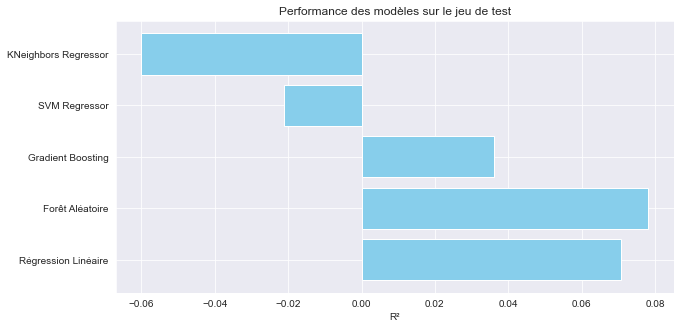

Le meilleur modèle est : Forêt Aléatoire


In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

models = {
    "Régression Linéaire": LinearRegression(),
    "Forêt Aléatoire": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVM Regressor": SVR(),
    "KNeighbors Regressor": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, y_pred)
    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse = mean_squared_error(y_test, y_pred)

    results.append({
        "Modèle": name,
        "R² Train": train_r2,
        "R² Test": test_r2,
        "MSE Train": train_mse,
        "MSE Test": test_mse
    })

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.barh(results_df["Modèle"], results_df["R² Test"], color='skyblue')
plt.xlabel("R²")
plt.title("Performance des modèles sur le jeu de test")
plt.show()

best_model_name = results_df.loc[results_df["R² Test"].idxmax(), "Modèle"]
print(f"Le meilleur modèle est : {best_model_name}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Meilleurs paramètres : {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Meilleur R² : 0.09049285082040359


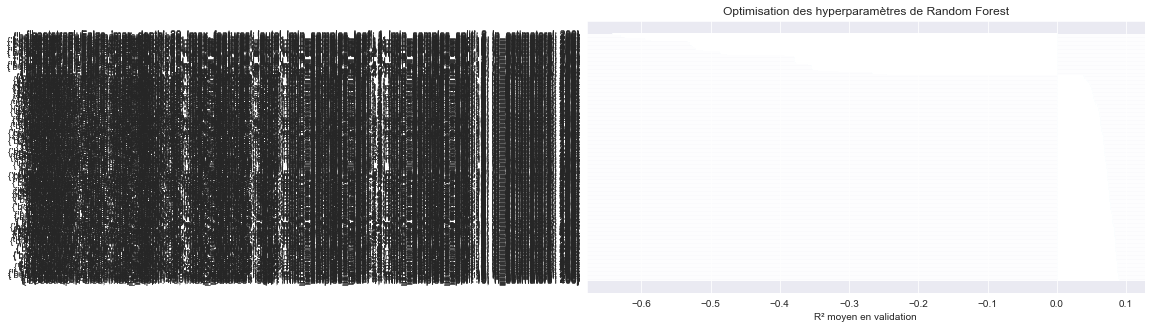

R² Train : 0.4981437024758866
R² Test : 0.09903517415546248
MSE Train : 1448.0846672181885
MSE Test : 3041.5648283391674


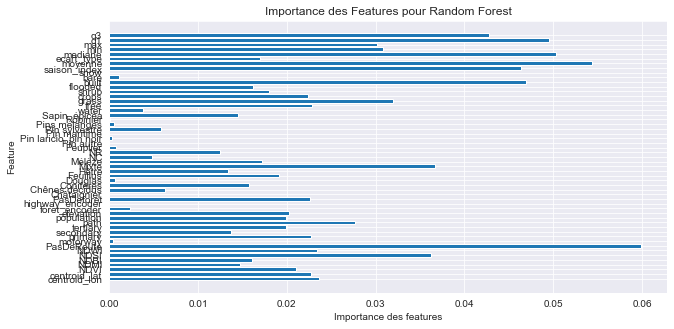

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],  # Nombre d'arbres
    'max_depth': [None, 10, 20, 30],  # Profondeur des arbres
    'min_samples_split': [2, 5, 10],  # Nombre minimum d'échantillons pour diviser un nœud
    'min_samples_leaf': [1, 2, 4],  # Nombre minimum d'échantillons dans un nœud terminal
    'max_features': ['auto', 'sqrt', 'log2'],  # Nombre de caractéristiques à utiliser
    'bootstrap': [True, False]  # Utiliser le bootstrap
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring="r2", n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)

results_sorted = results.sort_values(by="mean_test_score", ascending=False)

best_params = grid_search.best_params_
print(f"Meilleurs paramètres : {best_params}")
print(f"Meilleur R² : {grid_search.best_score_}")

plt.figure(figsize=(10, 5))
plt.barh(results_sorted["params"].astype(str), results_sorted["mean_test_score"], color='skyblue')
plt.xlabel("R² moyen en validation")
plt.title("Optimisation des hyperparamètres de Random Forest")
plt.show()

best_rf = grid_search.best_estimator_

y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

print(f"R² Train : {train_r2}")
print(f"R² Test : {test_r2}")
print(f"MSE Train : {train_mse}")
print(f"MSE Test : {test_mse}")

plt.figure(figsize=(10, 5))
plt.barh(X_train.columns, best_rf.feature_importances_)
plt.xlabel("Importance des features")
plt.ylabel("Feature")
plt.title("Importance des Features pour Random Forest")
plt.show()

In [ ]:
"""Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Meilleurs paramètres : {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}"""

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_rf = grid_search.best_estimator_

y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

metrics = {
    "Dataset": ["Train", "Test"],
    "MAE": [
        mean_absolute_error(y_train, y_pred_train),
        mean_absolute_error(y_test, y_pred_test)
    ],
    "MSE": [
        mean_squared_error(y_train, y_pred_train),
        mean_squared_error(y_test, y_pred_test)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        np.sqrt(mean_squared_error(y_test, y_pred_test))
    ],
    "R²": [
        r2_score(y_train, y_pred_train),
        r2_score(y_test, y_pred_test)
    ]
}

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

  Dataset        MAE          MSE       RMSE        R²
0   Train  25.673363  1448.084667  38.053708  0.498144
1    Test  38.709073  3041.564828  55.150384  0.099035
